In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from skimage.feature import hog
from skimage import exposure
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_curve, auc)

In [2]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
X = np.concatenate((train_images, test_images), axis=0)
y = np.concatenate((train_labels, test_labels), axis=0)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
idx_7 = np.where(y == 7)[0][:1000]
idx_9 = np.where(y == 9)[0][:1000]
indices = np.concatenate([idx_7, idx_9])
X_filtered, y_filtered = X[indices], y[indices]

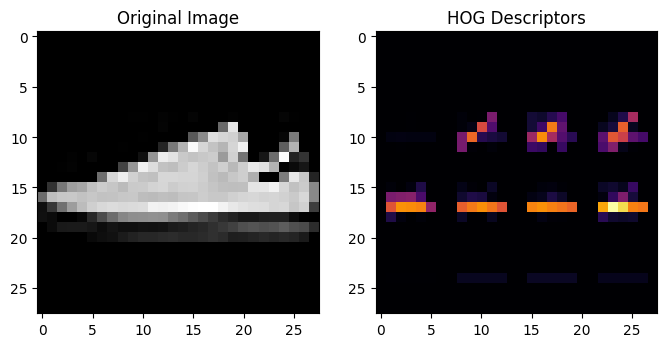

In [4]:
def extract_hog_with_vis(images):
    hog_feats = []
    # Visualize the first image for the report
    fd, hog_image = hog(images[0], orientations=9, pixels_per_cell=(7, 7),
                        cells_per_block=(2, 2), visualize=True)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1); plt.imshow(images[0], cmap='gray'); plt.title("Original Image")
    plt.subplot(1, 2, 2); plt.imshow(hog_image, cmap='inferno'); plt.title("HOG Descriptors")
    plt.show()

    for img in images:
        fd = hog(img, orientations=9, pixels_per_cell=(7, 7), cells_per_block=(2, 2))
        hog_feats.append(fd)
    return np.array(hog_feats)

X_hog = extract_hog_with_vis(X_filtered)

In [5]:
# 3. PRE-PROCESSING (Crucial for SVM/KNN)
# Scaling ensures features with higher variance don't dominate the distance metric
scaler = StandardScaler()
X_hog_scaled = scaler.fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(X_hog_scaled, y_filtered, test_size=0.3, random_state=42)

# 4. MODEL DEFINITIONS
models = {
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "LogReg": LogisticRegression(max_iter=1000, C=1.0),
    "Linear SVM": SVC(kernel='linear', probability=True)
}

In [6]:
results = {}
plt.figure(figsize=(10, 6))

for name, clf in models.items():
    # Training
    t0 = time.time()
    clf.fit(X_train, y_train)
    t_train = time.time() - t0

<Figure size 1000x600 with 0 Axes>

In [7]:
    t1 = time.time()
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    t_test = time.time() - t1

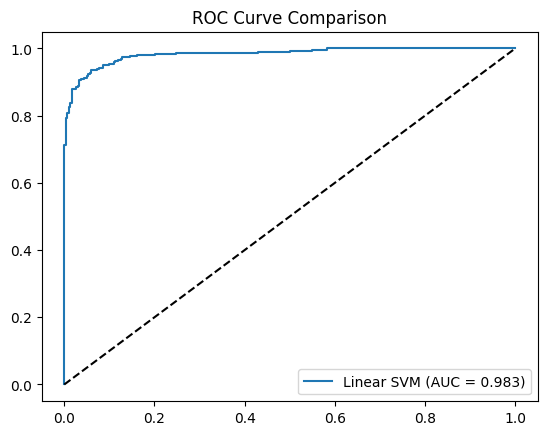

In [8]:
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=9)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    results[name] = {
        "Acc": accuracy_score(y_test, y_pred),
        "TrainTime": t_train,
        "TestTime": t_test,
        "CM": confusion_matrix(y_test, y_pred)
    }

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"{'Classifier':<20} | {'Accuracy':<8} | {'Precision':<10} | {'Recall':<8} | {'F1-Score':<8}")
print("-" * 65)

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    # Using 'weighted' because it accounts for any slight class imbalance in the test split
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"{name:<20} | {acc:<8.4f} | {prec:<10.4f} | {rec:<8.4f} | {f1:<8.4f}")
    
    # Print Confusion Matrix
    print(f"\nConfusion Matrix for {name}:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 30)

Classifier           | Accuracy | Precision  | Recall   | F1-Score
-----------------------------------------------------------------
KNN (k=3)            | 0.9483   | 0.9483     | 0.9483   | 0.9483  

Confusion Matrix for KNN (k=3):
[[287  15]
 [ 16 282]]
------------------------------
KNN (k=5)            | 0.9500   | 0.9501     | 0.9500   | 0.9500  

Confusion Matrix for KNN (k=5):
[[285  17]
 [ 13 285]]
------------------------------
LogReg               | 0.9500   | 0.9500     | 0.9500   | 0.9500  

Confusion Matrix for LogReg:
[[286  16]
 [ 14 284]]
------------------------------
Linear SVM           | 0.9317   | 0.9319     | 0.9317   | 0.9317  

Confusion Matrix for Linear SVM:
[[278  24]
 [ 17 281]]
------------------------------


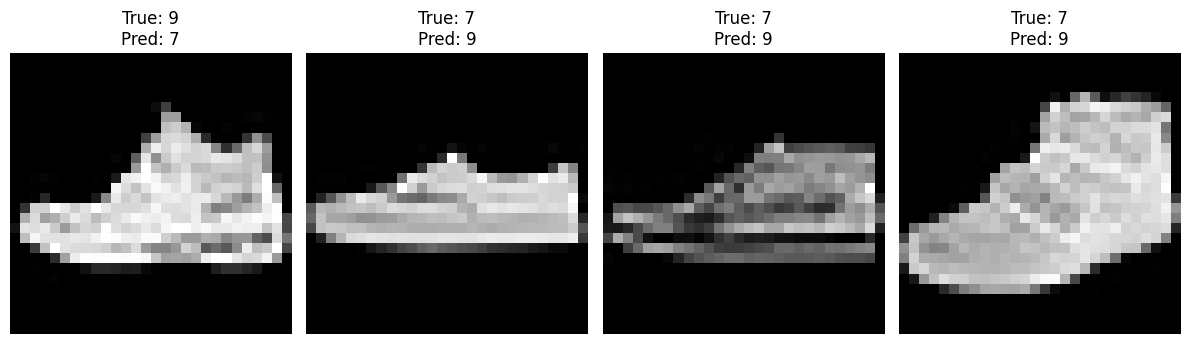

In [12]:
# Create a parallel split for the actual images (not just HOG features)
_, X_images_test, _, _ = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42)

# Find where SVM was wrong
y_pred_svm = models["Linear SVM"].predict(X_test)
mis_idx = np.where(y_pred_svm != y_test)[0]

# Now plot them correctly
plt.figure(figsize=(12, 5))
for i, idx in enumerate(mis_idx[:4]): # Show first 4 errors
    plt.subplot(1, 4, i+1)
    plt.imshow(X_images_test[idx], cmap='gray') # This draws the image
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_svm[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()